# **Estudio del QAOA con normalización del Hamiltoniano**

In [2]:
%load_ext autoreload
%autoreload 2

from modules import schnorr_lattice as sl
from modules import qaoa
from modules import utils

import numpy as np
import matplotlib.cm as cm

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import seaborn as sns

from tqdm.notebook import tqdm

import random

import pandas as pd

In [2]:
seed = 42

q = 10
l = 1
c = 3

In [3]:
def normalize_hamiltonian(Hc):
    norma = np.max(np.abs(Hc.coeffs))

    nHc = Hc.copy()
    nHc.coeffs = nHc.coeffs / norma
    return nHc

## **1. Visualización del paisaje para p > 1**

En la siguiente sección se mostrará el paisaje de valores de energia del espacio de búsqueda del optimizador clásico para $2*p$ ángulos

### **1.1 Caso de N = 1961**

In [4]:
N = 1961

cvp = sl.schnorrCVP(N, 1.5, l, seed)

instance = cvp.generate_cvp(q)

babresult = cvp.babai_algorithm(instance, delta = 0.75)

El numero de bits de N = 1961 es m = 11
La dimension del reticulo que vamos a tratar es n = 3
La cota smooth que vamos a tomar: 18
B = 
[ 2 0 0 22 ]
[ 0 1 0 35 ]
[ 0 0 1 51 ]
t = 
(0, 0, 0, 240)


In [5]:
qubo = qaoa.define_qubo(babresult.D, babresult.res_vector, babresult.step_sign, cvp.n)
Hc, offset = qaoa.define_hamiltonian(qubo)
print(f'Cost Hamiltonian = {Hc}')

Cost Hamiltonian = SparsePauliOp(['IIZ', 'IZI', 'ZII', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[-11. +0.j,  -5.5+0.j, -19.5+0.j,   0.5+0.j,   2.5+0.j,   2. +0.j])


In [6]:
nHc = normalize_hamiltonian(Hc)
print(f'Normalized cost hamiltonian = {nHc}')

Normalized cost hamiltonian = SparsePauliOp(['IIZ', 'IZI', 'ZII', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[-0.56410256+0.j, -0.28205128+0.j, -1.        +0.j,  0.02564103+0.j,
  0.12820513+0.j,  0.1025641 +0.j])


#### Evaluamos para p = 1

In [7]:
p = 1
circuit1 = qaoa.construct_circuit(Hc, reps = p)
ncircuit1 = qaoa.construct_circuit(nHc, reps = p)

In [8]:
grid = 300

beta_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(beta_grid, gamma_grid)

search_space1 = np.column_stack([B.ravel(), G.ravel()])

In [9]:
evals1 = qaoa.evaluate_params(circuit1, Hc, search_space1)
nevals1 = qaoa.evaluate_params(ncircuit1, nHc, search_space1)

Z1 = evals1.reshape(grid, grid)
nZ1 = nevals1.reshape(grid, grid)

In [10]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

zmin, zmax = Z1.min(), Z1.max()

nzmin, nzmax = nZ1.min(), nZ1.max()


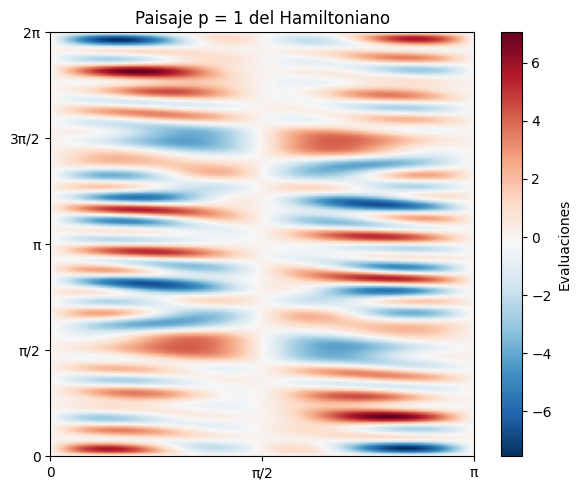

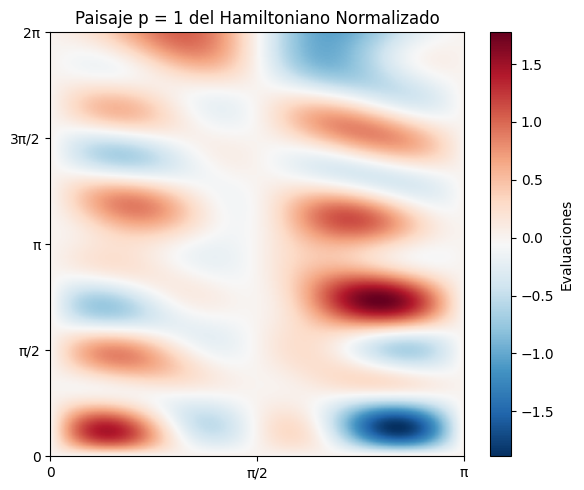

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6, 5))
im1 = ax1.imshow(
    Z1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = zmin, vmax = zmax
)
fig1.colorbar(im1, ax = ax1, label = "Evaluaciones")

ax1.set_xticks(ticks_b), ax1.set_xticklabels(lbls_b)
ax1.set_yticks(ticks_g), ax1.set_yticklabels(lbls_g)

ax1.set_title("Paisaje p = 1 del Hamiltoniano")
fig1.tight_layout()
fig1.savefig(f"figures/estudio_3qubits_hamiltoniano_p1.png", dpi = 150)


fig2, ax2 = plt.subplots(figsize = (6, 5))
im2 = ax2.imshow(
    nZ1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = nzmin, vmax = nzmax
)
fig2.colorbar(im2, ax = ax2, label = "Evaluaciones")

ax2.set_xticks(ticks_b), ax2.set_xticklabels(lbls_b)
ax2.set_yticks(ticks_g), ax2.set_yticklabels(lbls_g)

ax2.set_title("Paisaje p = 1 del Hamiltoniano Normalizado")
fig2.tight_layout()
fig2.savefig(f"figures/estudio_3qubits_hamiltoniano_normalizado_p1.png", dpi = 150)
plt.show()


#### Evaluamos para p = 2

In [7]:
p = 2
circuit2 = qaoa.construct_circuit(Hc, reps = p)
ncircuit2 = qaoa.construct_circuit(nHc, reps = p)

In [8]:
_, optparams = qaoa.qaoa_algorithm(circuit2, Hc)
_, noptparams = qaoa.qaoa_algorithm(ncircuit2, nHc)

print(optparams)
print(noptparams)

{'β[0]': np.float64(0.08538828152319158), 'β[1]': np.float64(-0.8239965091472973), 'γ[0]': np.float64(0.5212779725896092), 'γ[1]': np.float64(-0.48055740529264157)}
{'β[0]': np.float64(-0.07066670120502672), 'β[1]': np.float64(-0.7153499346537269), 'γ[0]': np.float64(0.530059141591158), 'γ[1]': np.float64(0.33448841816003716)}


In [ ]:
fixed = list(optparams.values())
nfixed = list(optparams.values())
grid = 300

variables = list(optparams.keys())

betabound = (0, np.pi)
gammabound = (0, 2*np.pi)

grids = {var: np.linspace(0, np.pi, grid) if i < p else np.linspace(0, 2*np.pi, grid) for i, var in enumerate(variables)}

beta_ticklabel = (["0", "π/2", "π"], [0, np.pi/2, np.pi])
gamma_ticklabel = (["0", "π/2", "π", "3π/2", "2π"], [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

In [ ]:
all_z = {}
nall_z = {}
for i, var_y in tqdm(enumerate(variables), desc = "var_y"):
    for j, var_x in tqdm(enumerate(variables), desc = "var_x"):
        if i == j:
            grid_args = []
            ngrid_args = []
            for v in grids[var_y]:
                args = fixed.copy()
                nargs = nfixed.copy()

                args[i] = v
                nargs[i] = v
                grid_args.append(args)
                ngrid_args.append(nargs)

            vals = qaoa.evaluate_params(circuit2, Hc, grid_args)
            nvals = qaoa.evaluate_params(ncircuit2, nHc, ngrid_args)

            all_z[(i, i)] = vals
            nall_z[(i, i)] = nvals

        else:
            gy = grids[var_y]
            gx = grids[var_x]

            X, Y = np.meshgrid(gx, gy)

            search_space = np.column_stack([X.ravel(), Y.ravel()])

            grid_args = []
            ngrid_args = []
            for point in search_space:
                args = fixed.copy()
                nargs = nfixed.copy()
                args[j] = point[0]
                args[i] = point[1]

                nargs[j] = point[0]
                nargs[i] = point[1]

                grid_args.append(args)
                ngrid_args.append(nargs)

            vals = qaoa.evaluate_params(circuit2, Hc, grid_args)
            nvals = qaoa.evaluate_params(ncircuit2, nHc, ngrid_args)

            all_z[(i, j)] = vals.reshape(grid, grid)
            nall_z[(i, j)] = nvals.reshape(grid, grid) 




var_y: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

In [11]:
vmin = min(Z.min() for Z in all_z.values())
vmax = max(Z.max() for Z in all_z.values())

nvmin = min(Z.min() for Z in nall_z.values())
nvmax = max(Z.max() for Z in nall_z.values())
norm = Normalize(vmin=vmin, vmax=vmax)
nnorm = Normalize(vmin = nvmin, vmax = nvmax)


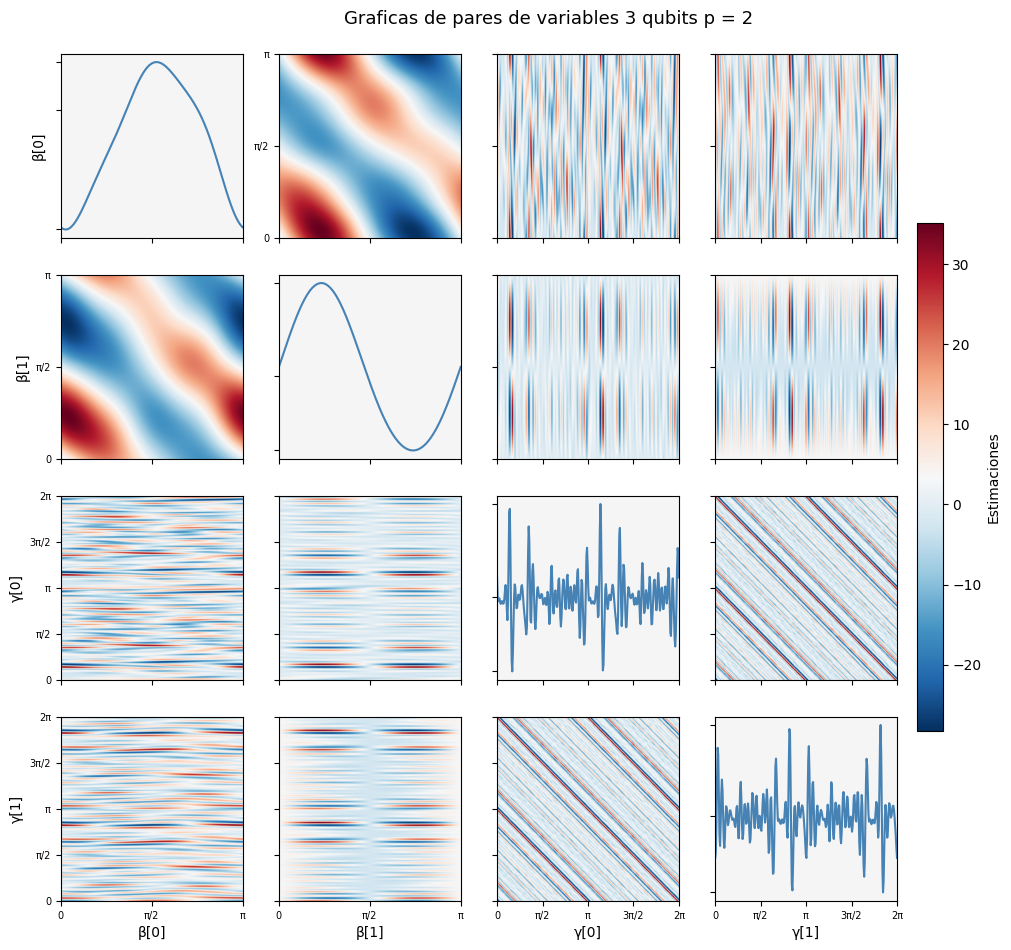

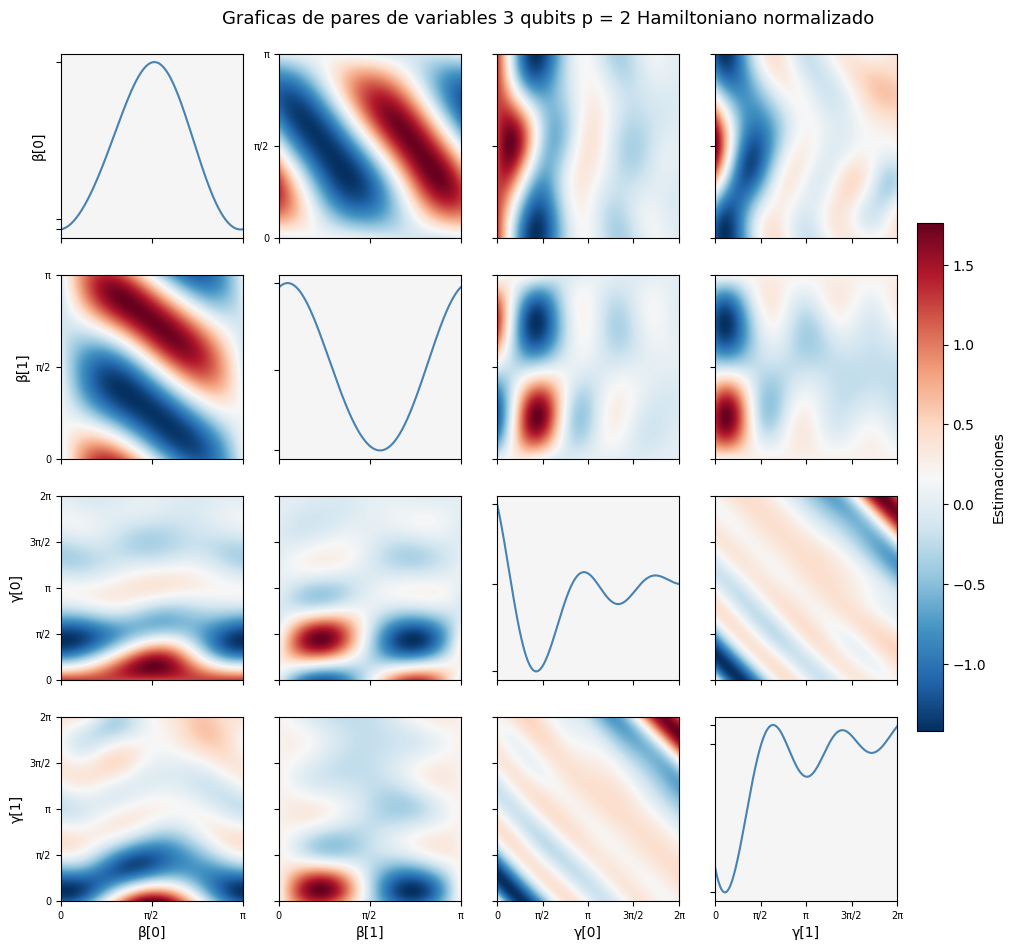

In [14]:
fig, axes = plt.subplots(2*p, 2*p, figsize = (13, 11))

nfig, naxes = plt.subplots(2*p, 2*p, figsize = (13, 11))

fig.suptitle("Graficas de pares de variables 3 qubits p = 2", fontsize = 13, y = 0.92)
nfig.suptitle("Graficas de pares de variables 3 qubits p = 2 Hamiltoniano normalizado", fontsize = 13, y = 0.92)

for i, var_y in enumerate(variables):
    gy = grids[var_y]
    lo_y, hi_y = betabound if i < p else gammabound
    labels_y, ticks_y = beta_ticklabel if i < p else gamma_ticklabel

    for j, var_x in enumerate(variables):
        ax = axes[i][j]
        nax = naxes[i][j]

        gx = grids[var_x]

        lo_x, hi_x = betabound if j < p else gammabound

        labels_x, ticks_x = beta_ticklabel if j < p else gamma_ticklabel

        if i == j:

            ax.plot(grids[var_y], all_z[(i, j)], color='steelblue', linewidth=1.5)
            ax.set_xlim(lo_y, hi_y)
            ax.set_facecolor("#f5f5f5ff")

            vals_min = min(all_z[(i, j)])
            vals_max = max(all_z[(i, j)])

            ax.set_yticks([vals_min, 0, vals_max])
            ax.set_yticklabels([])


            nax.plot(grids[var_y], nall_z[(i, j)], color='steelblue', linewidth=1.5)
            nax.set_xlim(lo_y, hi_y)
            nax.set_facecolor("#f5f5f5ff")

            vals_min = min(nall_z[(i, j)])
            vals_max = max(nall_z[(i, j)])

            nax.set_yticks([vals_min, 0, vals_max])
            nax.set_yticklabels([])


            
        else:
            Z = all_z[(i, j)]
            nZ = nall_z[(i, j)]

            ax.imshow(Z, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            nax.imshow(nZ, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            #ax.plot(fixed[j] % np.pi if j < p else fixed[j] % (2*np.pi), fixed[i]% np.pi if i < p else fixed[i]% (2*np.pi), 'r*', markersize=8)

            ax.set_yticks(ticks_y)
            nax.set_yticks(ticks_y)
            if j == 0 and i > 0:
                ax.set_yticklabels(labels_y, fontsize=7)
                nax.set_yticklabels(labels_y, fontsize=7)
            elif j == 1 and i == 0: 
                ax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
                nax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
            else:
                ax.set_yticklabels([], fontsize = 7)
                nax.set_yticklabels([], fontsize = 7)
        

        

        ax.set_xticks(ticks_x)
        ax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        nax.set_xticks(ticks_x)
        nax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        

        if i == 2*p - 1:
            ax.set_xlabel(var_x, fontsize=10)
            nax.set_xlabel(var_x, fontsize=10)
        if j == 0:
            ax.set_ylabel(var_y, fontsize=10)
            nax.set_ylabel(var_y, fontsize=10)
        



#figp2.subplots_adjust(right=0.88, top=0.90, hspace=0.15, wspace=0.15)

fig.colorbar(cm.ScalarMappable( norm = norm, cmap="RdBu_r"),
             ax=axes, label='Estimaciones', shrink=0.6, pad=0.02)

nfig.colorbar(cm.ScalarMappable( norm = nnorm, cmap="RdBu_r"),
             ax=naxes, label='Estimaciones', shrink=0.6, pad=0.02)

#plt.tight_layout()

fig.savefig("figures/estudio_3qubits_hamiltoniano_p2.png", dpi=150)
nfig.savefig("figures/estudio_3qubits_hamiltoniano_normalizado_p2.png", dpi=150)

plt.show()
        

### **1.2 Caso de N = 48567227**

In [4]:
N = 48567227

cvp = sl.schnorrCVP(N, 3, 1, seed)

instance = cvp.generate_cvp(q)

babresult = cvp.babai_algorithm(instance, delta = 0.75)

qubo = qaoa.define_qubo(babresult.D, babresult.res_vector, babresult.step_sign, cvp.n)
Hc, offset = qaoa.define_hamiltonian(qubo)
print(f'Cost Hamiltonian = {Hc}')

nHc = normalize_hamiltonian(Hc)
print(f'Normalized cost hamiltonian = {nHc}')

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5
La cota smooth que vamos a tomar: 50
B = 
[ 2 0 0 0 0  693 ]
[ 0 2 0 0 0 1099 ]
[ 0 0 1 0 0 1609 ]
[ 0 0 0 1 0 1946 ]
[ 0 0 0 0 3 2398 ]
t = 
(0, 0, 0, 0, 0, 17698)
Cost Hamiltonian = SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'ZIIII', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-34.5+0.j, -30.5+0.j, -19.5+0.j, -60.5+0.j,  11.5+0.j,   7. +0.j,
   5. +0.j,  -4.5+0.j,  10. +0.j,  -6. +0.j,  -8. +0.j,  17.5+0.j,
 -16. +0.j,  16.5+0.j, -23.5+0.j])
Normalized cost hamiltonian = SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'ZIIII', 'IZIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[-0.57024793+0.j, -0.50413223+0.j, -0.32231405+0.j, -1.        +0.j,
  0.19008264+0.j,  0.11570248+0.j,  0.08264463+0.j, -0.07438017+0.j,
  0.16528926+0.j, -0.09917355+0.j, -0

#### Evaluamos para p = 1

In [5]:
p = 1
circuit1 = qaoa.construct_circuit(Hc, reps = p)
ncircuit1 = qaoa.construct_circuit(nHc, reps = p)

In [6]:
grid = 300

beta_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(beta_grid, gamma_grid)

search_space1 = np.column_stack([B.ravel(), G.ravel()])

In [7]:
evals1 = qaoa.evaluate_params(circuit1, Hc, search_space1)
nevals1 = qaoa.evaluate_params(ncircuit1, nHc, search_space1)

Z1 = evals1.reshape(grid, grid)
nZ1 = nevals1.reshape(grid, grid)

In [8]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

zmin, zmax = Z1.min(), Z1.max()

nzmin, nzmax = nZ1.min(), nZ1.max()


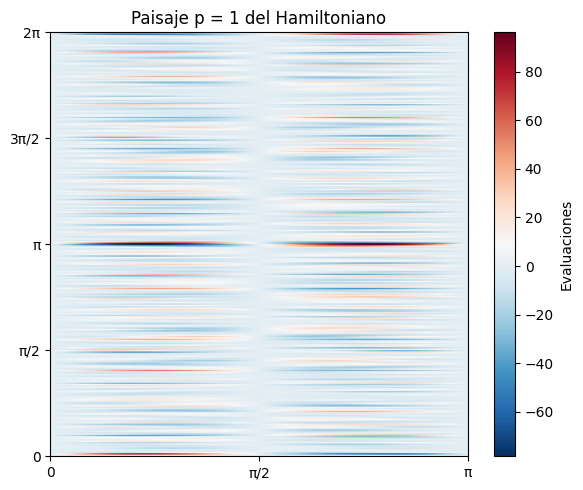

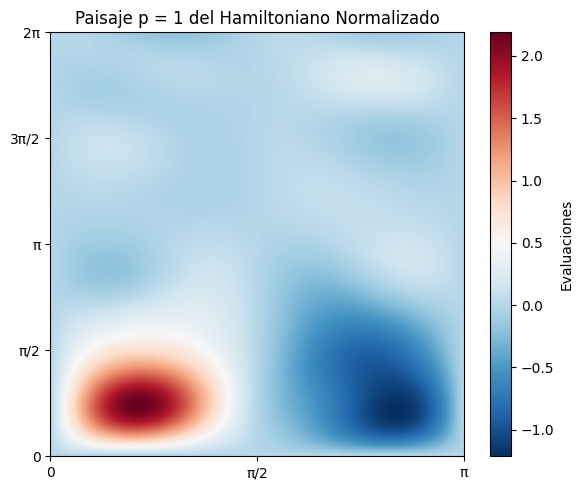

In [9]:
fig1, ax1 = plt.subplots(figsize = (6, 5))
im1 = ax1.imshow(
    Z1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = zmin, vmax = zmax
)
fig1.colorbar(im1, ax = ax1, label = "Evaluaciones")

ax1.set_xticks(ticks_b), ax1.set_xticklabels(lbls_b)
ax1.set_yticks(ticks_g), ax1.set_yticklabels(lbls_g)

ax1.set_title("Paisaje p = 1 del Hamiltoniano")
fig1.tight_layout()
fig1.savefig(f"figures/estudio_5qubits_hamiltoniano_p1.png", dpi = 150)


fig2, ax2 = plt.subplots(figsize = (6, 5))
im2 = ax2.imshow(
    nZ1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = nzmin, vmax = nzmax
)
fig2.colorbar(im2, ax = ax2, label = "Evaluaciones")

ax2.set_xticks(ticks_b), ax2.set_xticklabels(lbls_b)
ax2.set_yticks(ticks_g), ax2.set_yticklabels(lbls_g)

ax2.set_title("Paisaje p = 1 del Hamiltoniano Normalizado")
fig2.tight_layout()
fig2.savefig(f"figures/estudio_5qubits_hamiltoniano_normalizado_p1.png", dpi = 150)
plt.show()


#### Evaluamos para p = 2

In [10]:
p = 2
circuit2 = qaoa.construct_circuit(Hc, reps = p)
ncircuit2 = qaoa.construct_circuit(nHc, reps = p)

In [11]:
_, optparams = qaoa.qaoa_algorithm(circuit2, Hc)
_, noptparams = qaoa.qaoa_algorithm(ncircuit2, nHc)

print(optparams)
print(noptparams)

{'β[0]': np.float64(-0.025663360785060308), 'β[1]': np.float64(-0.5109393397154187), 'γ[0]': np.float64(0.06069077783889013), 'γ[1]': np.float64(-0.04941242553506758)}
{'β[0]': np.float64(-0.5661356796985711), 'β[1]': np.float64(-0.36540231087249875), 'γ[0]': np.float64(0.5452547730137793), 'γ[1]': np.float64(1.2656880121139018)}


In [12]:
fixed = list(optparams.values())
nfixed = list(optparams.values())
grid = 300

variables = list(optparams.keys())

betabound = (0, np.pi)
gammabound = (0, 2*np.pi)

grids = {var: np.linspace(0, np.pi, grid) if i < p else np.linspace(0, 2*np.pi, grid) for i, var in enumerate(variables)}

beta_ticklabel = (["0", "π/2", "π"], [0, np.pi/2, np.pi])
gamma_ticklabel = (["0", "π/2", "π", "3π/2", "2π"], [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

In [ ]:
all_z = {}
nall_z = {}
for i, var_y in tqdm(enumerate(variables), desc = "var_y"):
    for j, var_x in tqdm(enumerate(variables), desc = "var_x"):
        if i == j:
            grid_args = []
            ngrid_args = []
            for v in grids[var_y]:
                args = fixed.copy()
                nargs = nfixed.copy()

                args[i] = v
                nargs[i] = v
                grid_args.append(args)
                ngrid_args.append(nargs)

            vals = qaoa.evaluate_params(circuit2, Hc, grid_args)
            nvals = qaoa.evaluate_params(ncircuit2, nHc, ngrid_args)

            all_z[(i, i)] = vals
            nall_z[(i, i)] = nvals

        else:
            gy = grids[var_y]
            gx = grids[var_x]

            X, Y = np.meshgrid(gx, gy)

            search_space = np.column_stack([X.ravel(), Y.ravel()])

            grid_args = []
            ngrid_args = []
            for point in search_space:
                args = fixed.copy()
                nargs = nfixed.copy()
                args[j] = point[0]
                args[i] = point[1]

                nargs[j] = point[0]
                nargs[i] = point[1]

                grid_args.append(args)
                ngrid_args.append(nargs)

            vals = qaoa.evaluate_params(circuit2, Hc, grid_args)
            nvals = qaoa.evaluate_params(ncircuit2, nHc, ngrid_args)

            all_z[(i, j)] = vals.reshape(grid, grid)
            nall_z[(i, j)] = nvals.reshape(grid, grid) 




var_y: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

In [17]:
vmin = min(Z.min() for Z in all_z.values())
vmax = max(Z.max() for Z in all_z.values())

nvmin = min(Z.min() for Z in nall_z.values())
nvmax = max(Z.max() for Z in nall_z.values())
norm = Normalize(vmin=vmin, vmax=vmax)
nnorm = Normalize(vmin = nvmin, vmax = nvmax)

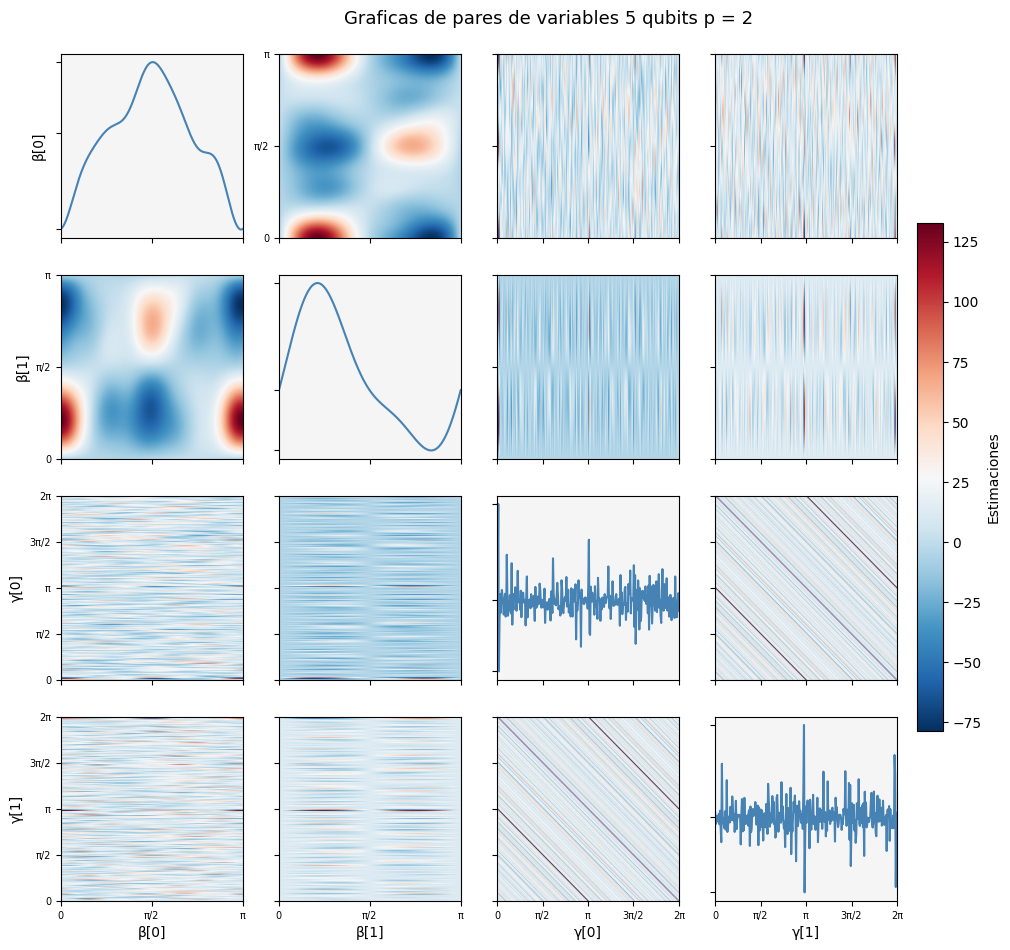

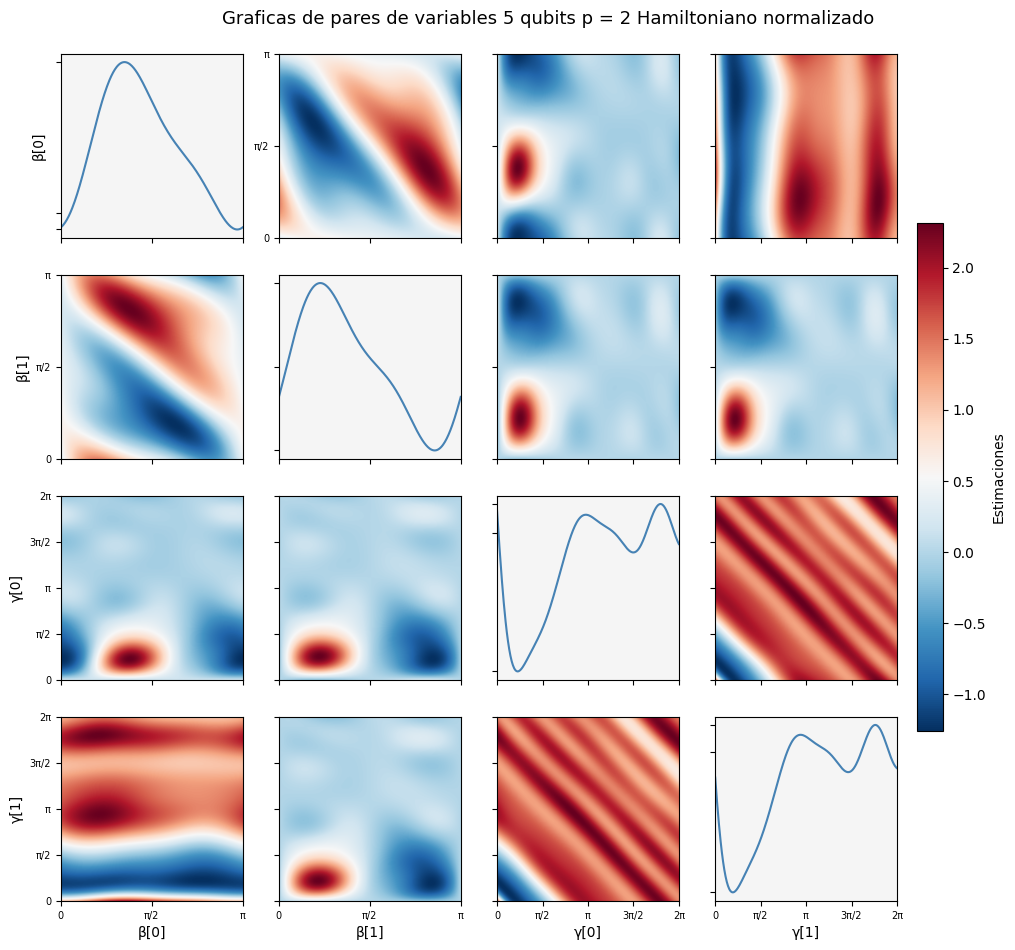

In [19]:
fig, axes = plt.subplots(2*p, 2*p, figsize = (13, 11))

nfig, naxes = plt.subplots(2*p, 2*p, figsize = (13, 11))

fig.suptitle("Graficas de pares de variables 5 qubits p = 2", fontsize = 13, y = 0.92)
nfig.suptitle("Graficas de pares de variables 5 qubits p = 2 Hamiltoniano normalizado", fontsize = 13, y = 0.92)

for i, var_y in enumerate(variables):
    gy = grids[var_y]
    lo_y, hi_y = betabound if i < p else gammabound
    labels_y, ticks_y = beta_ticklabel if i < p else gamma_ticklabel

    for j, var_x in enumerate(variables):
        ax = axes[i][j]
        nax = naxes[i][j]

        gx = grids[var_x]

        lo_x, hi_x = betabound if j < p else gammabound

        labels_x, ticks_x = beta_ticklabel if j < p else gamma_ticklabel

        if i == j:

            ax.plot(grids[var_y], all_z[(i, j)], color='steelblue', linewidth=1.5)
            ax.set_xlim(lo_y, hi_y)
            ax.set_facecolor("#f5f5f5ff")

            vals_min = min(all_z[(i, j)])
            vals_max = max(all_z[(i, j)])

            ax.set_yticks([vals_min, 0, vals_max])
            ax.set_yticklabels([])


            nax.plot(grids[var_y], nall_z[(i, j)], color='steelblue', linewidth=1.5)
            nax.set_xlim(lo_y, hi_y)
            nax.set_facecolor("#f5f5f5ff")

            vals_min = min(nall_z[(i, j)])
            vals_max = max(nall_z[(i, j)])

            nax.set_yticks([vals_min, 0, vals_max])
            nax.set_yticklabels([])


            
        else:
            Z = all_z[(i, j)]
            nZ = nall_z[(i, j)]

            ax.imshow(Z, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            nax.imshow(nZ, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            #ax.plot(fixed[j] % np.pi if j < p else fixed[j] % (2*np.pi), fixed[i]% np.pi if i < p else fixed[i]% (2*np.pi), 'r*', markersize=8)

            ax.set_yticks(ticks_y)
            nax.set_yticks(ticks_y)
            if j == 0 and i > 0:
                ax.set_yticklabels(labels_y, fontsize=7)
                nax.set_yticklabels(labels_y, fontsize=7)
            elif j == 1 and i == 0: 
                ax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
                nax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
            else:
                ax.set_yticklabels([], fontsize = 7)
                nax.set_yticklabels([], fontsize = 7)
        

        

        ax.set_xticks(ticks_x)
        ax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        nax.set_xticks(ticks_x)
        nax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        

        if i == 2*p - 1:
            ax.set_xlabel(var_x, fontsize=10)
            nax.set_xlabel(var_x, fontsize=10)
        if j == 0:
            ax.set_ylabel(var_y, fontsize=10)
            nax.set_ylabel(var_y, fontsize=10)
        



#figp2.subplots_adjust(right=0.88, top=0.90, hspace=0.15, wspace=0.15)

fig.colorbar(cm.ScalarMappable( norm = norm, cmap="RdBu_r"),
             ax=axes, label='Estimaciones', shrink=0.6, pad=0.02)

nfig.colorbar(cm.ScalarMappable( norm = nnorm, cmap="RdBu_r"),
             ax=naxes, label='Estimaciones', shrink=0.6, pad=0.02)

#plt.tight_layout()

fig.savefig("figures/estudio_5qubits_hamiltoniano_p2.png", dpi=150)
nfig.savefig("figures/estudio_5qubits_hamiltoniano_normalizado_p2.png", dpi=150)

plt.show()
        

### **1.3 Caso de N = 261980999226229**

In [10]:
from qiskit_aer.primitives import EstimatorV2

In [11]:
N = 261980999226229

cvp = sl.schnorrCVP(N, 4, 1.5, seed)

instance = cvp.generate_cvp(q)

babresult = cvp.babai_algorithm(instance, delta = 0.75)

qubo = qaoa.define_qubo(babresult.D, babresult.res_vector, babresult.step_sign, cvp.n)
Hc, offset = qaoa.define_hamiltonian(qubo)
print(f'Cost Hamiltonian = {Hc}')

nHc = normalize_hamiltonian(Hc)
print(f'Normalized cost hamiltonian = {nHc}')

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 13
La cota smooth que vamos a tomar: 338
B = 
[ 1 0 0 0 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 5 0 0 0 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 7 0 0 0 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 2 0 0 0 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 6 0 0 0 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 1 0 0 0 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 2 0 0 0 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 0 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 5 0 0 0 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 6 0 0 0 33673 ]
[ 0 0 0 0 0 0 0 0 0 0 3 0 0 34340 ]
[ 0 0 0 0 0 0 0 0 0 0 0 4 0 36109 ]
[ 0 0 0 0 0 0 0 0 0 0 0 0 4 37136 ]
t = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)
Cost Hamiltonian = SparsePauliOp(['IIIIIIIIIIIIZ', 'IIIIIIIIIIIZI', 'IIIIIIIIIIZII', 'IIIIIIIIIZIII', 'IIIIIIIIZIIII', 'IIIIIIIZIIIII', 'IIIIIZIIIIIII', 'IIIIZIIIIIIII', 'IIIZIIIIIIIII', 'IIZIIIIIIIIII', 'IZIIIIIIIIIII', 'ZIIIIIIIIIIII', 'IIIIIIZIIIIII', 'IIIIIIIIIIIZZ', 'IIIIIIIIIIZIZ', 'IIIIIIIIIZIIZ', 'IIIIIIIIZIIIZ', 'IIIIII

In [22]:
def execute_per_chunks_pair(chunk_size, circuit1, circuit2, Hc1, Hc2, params1, params2):

    simulator = EstimatorV2(options = {'backend_options': 
                                            {'method': 'automatic',
                                             'device': 'CPU',
                                             'max_parallel_threads': 0,
                                             'max_parallel_experiments': 0,
                                            }})
    chunks_vals1 = []
    chunks_vals2 = []
    neval = 0
    params_size = len(params1)
    for start in range(0, params_size, chunk_size):
        neval = min(chunk_size, params_size - start)
        args1 = params1[start: start + neval]
        args2 = params2[start:start + neval]

        pub = [(circuit1, Hc1, args1), (circuit2, Hc2, args2)]

        results = simulator.run(pub).result()
        #vals = qaoa.evaluate_params(circuit, Hc, args, simulator)

        chunks_vals1.append(results[0].data.evs)
        chunks_vals2.append(results[1].data.evs)

    evals1 = np.concatenate(chunks_vals1)
    evals2 = np.concatenate(chunks_vals2)
    return evals1, evals2

#### Evaluamos para p = 1

In [17]:
p = 1
circuit1 = qaoa.construct_circuit(Hc, reps = p)
ncircuit1 = qaoa.construct_circuit(nHc, reps = p)

In [18]:
grid = 300

beta_grid = np.linspace(0, np.pi, grid)
gamma_grid = np.linspace(0, 2*np.pi, grid)

B, G = np.meshgrid(beta_grid, gamma_grid)

search_space1 = np.column_stack([B.ravel(), G.ravel()])

In [23]:
#evals1 = execute_per_chunks(2000, circuit1, Hc, search_space1, grid)
#nevals1 = execute_per_chunks(2000, ncircuit1, nHc, search_space1, grid)

evals1, nevals1 = execute_per_chunks_pair(2000, circuit1, ncircuit1, Hc, nHc, search_space1, search_space1)

Z1 = evals1.reshape(grid, grid)
nZ1 = nevals1.reshape(grid, grid)

In [24]:
ticks_b = [0, np.pi/2, np.pi]
ticks_g = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

lbls_b = ["0", "π/2", "π"]
lbls_g = ["0", "π/2", "π", "3π/2", "2π"]

zmin, zmax = Z1.min(), Z1.max()

nzmin, nzmax = nZ1.min(), nZ1.max()


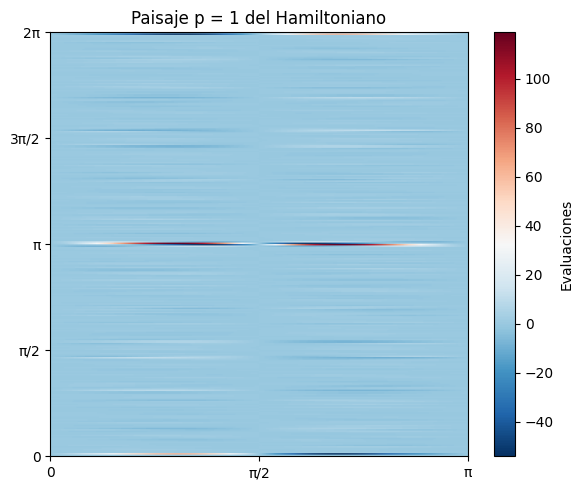

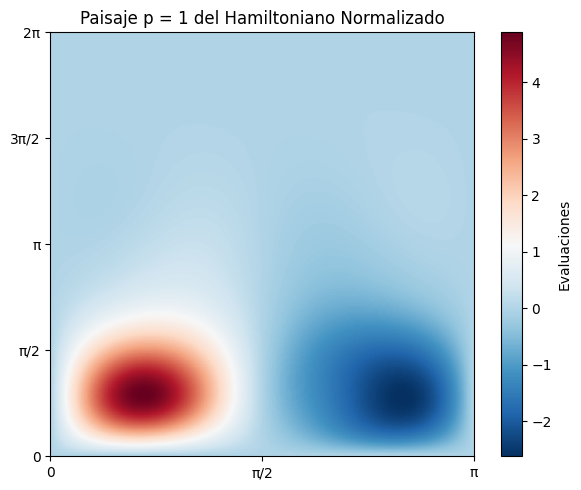

In [25]:
fig1, ax1 = plt.subplots(figsize = (6, 5))
im1 = ax1.imshow(
    Z1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = zmin, vmax = zmax
)
fig1.colorbar(im1, ax = ax1, label = "Evaluaciones")

ax1.set_xticks(ticks_b), ax1.set_xticklabels(lbls_b)
ax1.set_yticks(ticks_g), ax1.set_yticklabels(lbls_g)

ax1.set_title("Paisaje p = 1 del Hamiltoniano")
fig1.tight_layout()
fig1.savefig(f"figures/estudio_13qubits_hamiltoniano_p1.png", dpi = 150)


fig2, ax2 = plt.subplots(figsize = (6, 5))
im2 = ax2.imshow(
    nZ1, origin = "lower", aspect = "auto",
    extent = [0, np.pi, 0, 2*np.pi], cmap = "RdBu_r",
    vmin = nzmin, vmax = nzmax
)
fig2.colorbar(im2, ax = ax2, label = "Evaluaciones")

ax2.set_xticks(ticks_b), ax2.set_xticklabels(lbls_b)
ax2.set_yticks(ticks_g), ax2.set_yticklabels(lbls_g)

ax2.set_title("Paisaje p = 1 del Hamiltoniano Normalizado")
fig2.tight_layout()
fig2.savefig(f"figures/estudio_13qubits_hamiltoniano_normalizado_p1.png", dpi = 150)
plt.show()


#### Evaluamos para p = 2

In [26]:
p = 2
circuit2 = qaoa.construct_circuit(Hc, reps = p)
ncircuit2 = qaoa.construct_circuit(nHc, reps = p)

In [27]:
_, optparams = qaoa.qaoa_algorithm(circuit2, Hc)
_, noptparams = qaoa.qaoa_algorithm(ncircuit2, nHc)

print(optparams)
print(noptparams)

{'β[0]': np.float64(0.5260739554368571), 'β[1]': np.float64(0.001669654482994851), 'γ[0]': np.float64(-0.006831065112038057), 'γ[1]': np.float64(-1.2992080919322915)}
{'β[0]': np.float64(-0.6019762147059391), 'β[1]': np.float64(-0.29423026583446105), 'γ[0]': np.float64(0.6351613029681125), 'γ[1]': np.float64(1.761136006287389)}


In [29]:
fixed = list(optparams.values())
nfixed = list(optparams.values())
grid = 300

variables = list(optparams.keys())

betabound = (0, np.pi)
gammabound = (0, 2*np.pi)

grids = {var: np.linspace(0, np.pi, grid) if i < p else np.linspace(0, 2*np.pi, grid) for i, var in enumerate(variables)}

beta_ticklabel = (["0", "π/2", "π"], [0, np.pi/2, np.pi])
gamma_ticklabel = (["0", "π/2", "π", "3π/2", "2π"], [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])

In [30]:
all_z = {}
nall_z = {}
for i, var_y in tqdm(enumerate(variables), desc = "var_y"):
    for j, var_x in tqdm(enumerate(variables), desc = "var_x"):
        if i == j:
            grid_args = []
            ngrid_args = []
            for v in grids[var_y]:
                args = fixed.copy()
                nargs = nfixed.copy()

                args[i] = v
                nargs[i] = v
                grid_args.append(args)
                ngrid_args.append(nargs)

            #vals = execute_per_chunks(2000, circuit2, Hc, grid_args, grid)
            #nvals = execute_per_chunks(2000, ncircuit2, nHc, ngrid_args, grid)

            vals, nvals = execute_per_chunks_pair(2000, circuit2, ncircuit2, Hc, nHc, grid_args, ngrid_args)
            
            all_z[(i, i)] = vals
            nall_z[(i, i)] = nvals

        else:
            gy = grids[var_y]
            gx = grids[var_x]

            X, Y = np.meshgrid(gx, gy)

            search_space = np.column_stack([X.ravel(), Y.ravel()])

            grid_args = []
            ngrid_args = []
            for point in search_space:
                args = fixed.copy()
                nargs = nfixed.copy()
                args[j] = point[0]
                args[i] = point[1]

                nargs[j] = point[0]
                nargs[i] = point[1]

                grid_args.append(args)
                ngrid_args.append(nargs)
            
            #vals = execute_per_chunks(2000, circuit2, Hc, grid_args, grid)
            #nvals = execute_per_chunks(2000, ncircuit2, nHc, ngrid_args, grid)
            vals, nvals = execute_per_chunks_pair(2000, circuit2, ncircuit2, Hc, nHc, grid_args, ngrid_args)

    
            all_z[(i, j)] = vals.reshape(grid, grid)
            nall_z[(i, j)] = nvals.reshape(grid, grid) 


var_y: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

var_x: 0it [00:00, ?it/s]

In [33]:
vmin = min(Z.min() for Z in all_z.values())
vmax = max(Z.max() for Z in all_z.values())

nvmin = min(Z.min() for Z in nall_z.values())
nvmax = max(Z.max() for Z in nall_z.values())
norm = Normalize(vmin=vmin, vmax=vmax)
nnorm = Normalize(vmin = nvmin, vmax = nvmax)

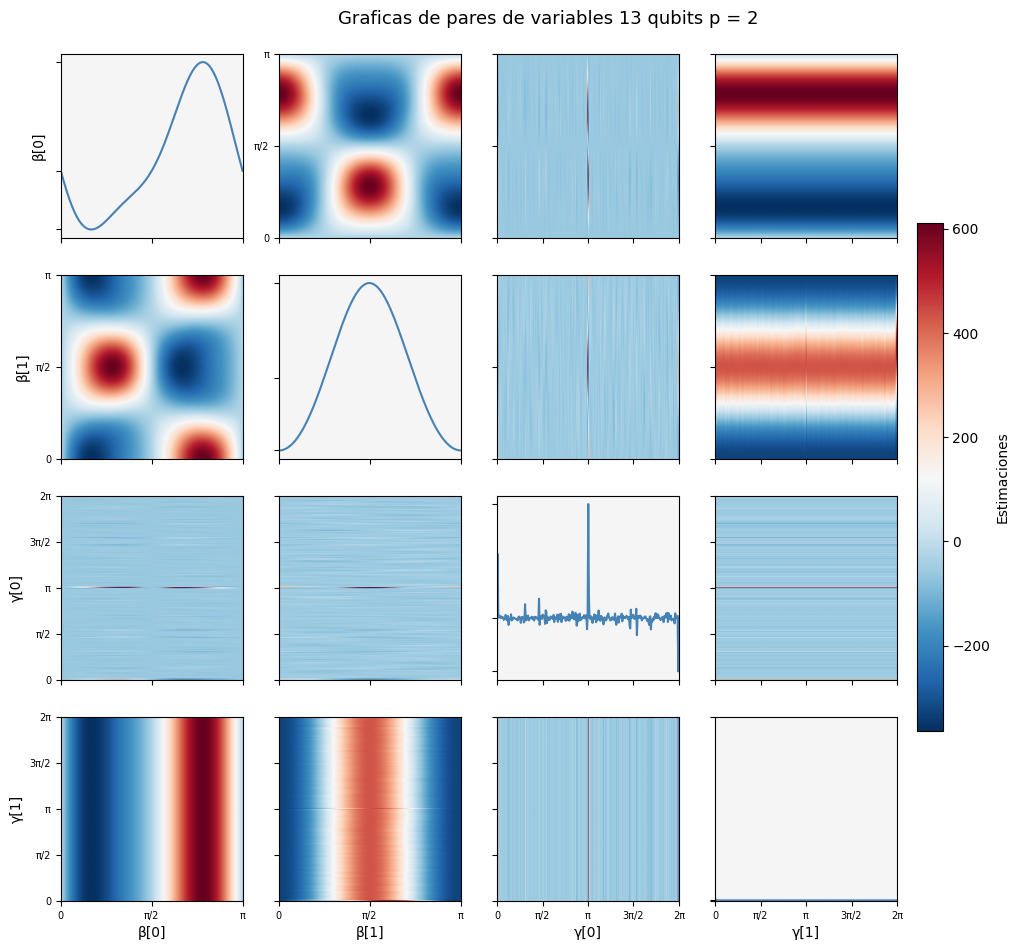

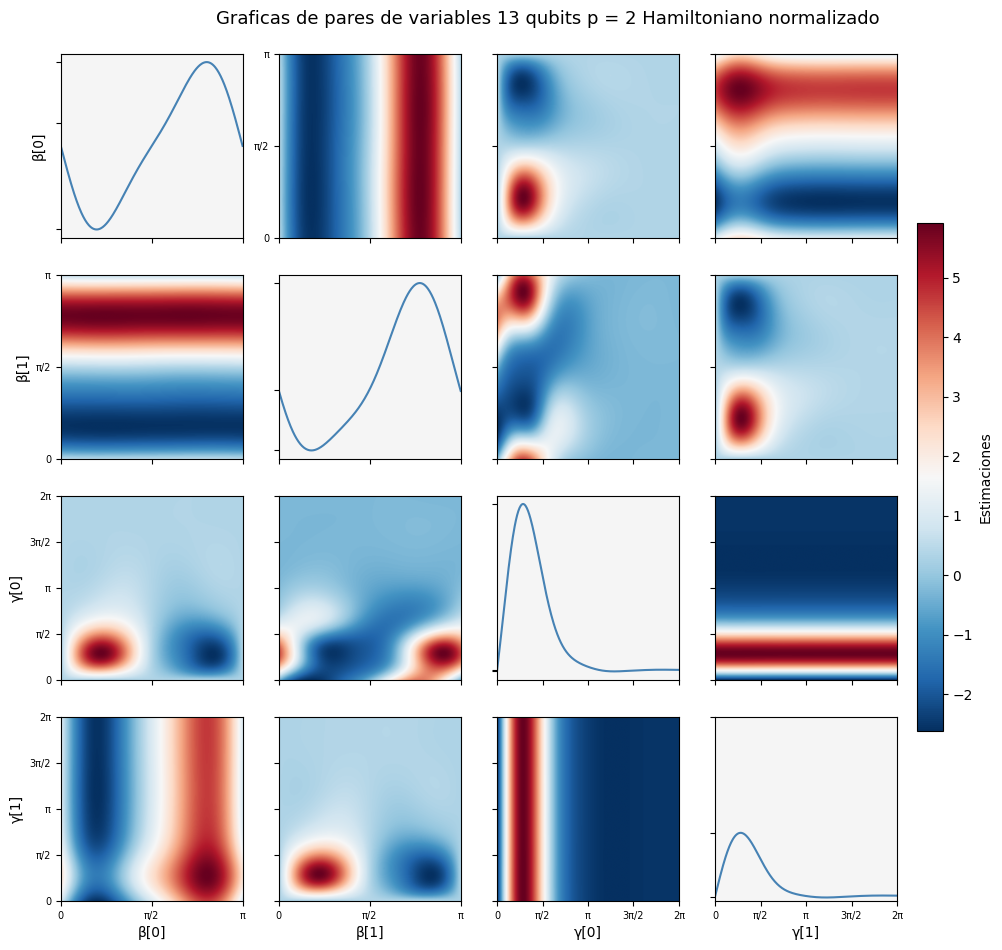

In [34]:
fig, axes = plt.subplots(2*p, 2*p, figsize = (13, 11))

nfig, naxes = plt.subplots(2*p, 2*p, figsize = (13, 11))

fig.suptitle("Graficas de pares de variables 13 qubits p = 2", fontsize = 13, y = 0.92)
nfig.suptitle("Graficas de pares de variables 13 qubits p = 2 Hamiltoniano normalizado", fontsize = 13, y = 0.92)

for i, var_y in enumerate(variables):
    gy = grids[var_y]
    lo_y, hi_y = betabound if i < p else gammabound
    labels_y, ticks_y = beta_ticklabel if i < p else gamma_ticklabel

    for j, var_x in enumerate(variables):
        ax = axes[i][j]
        nax = naxes[i][j]

        gx = grids[var_x]

        lo_x, hi_x = betabound if j < p else gammabound

        labels_x, ticks_x = beta_ticklabel if j < p else gamma_ticklabel

        if i == j:

            ax.plot(grids[var_y], all_z[(i, j)], color='steelblue', linewidth=1.5)
            ax.set_xlim(lo_y, hi_y)
            ax.set_facecolor("#f5f5f5ff")

            vals_min = min(all_z[(i, j)])
            vals_max = max(all_z[(i, j)])

            ax.set_yticks([vals_min, 0, vals_max])
            ax.set_yticklabels([])


            nax.plot(grids[var_y], nall_z[(i, j)], color='steelblue', linewidth=1.5)
            nax.set_xlim(lo_y, hi_y)
            nax.set_facecolor("#f5f5f5ff")

            vals_min = min(nall_z[(i, j)])
            vals_max = max(nall_z[(i, j)])

            nax.set_yticks([vals_min, 0, vals_max])
            nax.set_yticklabels([])


            
        else:
            Z = all_z[(i, j)]
            nZ = nall_z[(i, j)]

            ax.imshow(Z, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            nax.imshow(nZ, origin='lower', aspect='auto', cmap="RdBu_r", 
                      extent=[lo_x, hi_x, lo_y, hi_y])
            
            #ax.plot(fixed[j] % np.pi if j < p else fixed[j] % (2*np.pi), fixed[i]% np.pi if i < p else fixed[i]% (2*np.pi), 'r*', markersize=8)

            ax.set_yticks(ticks_y)
            nax.set_yticks(ticks_y)
            if j == 0 and i > 0:
                ax.set_yticklabels(labels_y, fontsize=7)
                nax.set_yticklabels(labels_y, fontsize=7)
            elif j == 1 and i == 0: 
                ax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
                nax.set_yticklabels(labels_y, fontsize = 7, ha = 'right')
            else:
                ax.set_yticklabels([], fontsize = 7)
                nax.set_yticklabels([], fontsize = 7)
        

        

        ax.set_xticks(ticks_x)
        ax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        nax.set_xticks(ticks_x)
        nax.set_xticklabels(labels_x if i == 2*p - 1 else [], fontsize=7)

        

        if i == 2*p - 1:
            ax.set_xlabel(var_x, fontsize=10)
            nax.set_xlabel(var_x, fontsize=10)
        if j == 0:
            ax.set_ylabel(var_y, fontsize=10)
            nax.set_ylabel(var_y, fontsize=10)
        



#figp2.subplots_adjust(right=0.88, top=0.90, hspace=0.15, wspace=0.15)

fig.colorbar(cm.ScalarMappable( norm = norm, cmap="RdBu_r"),
             ax=axes, label='Estimaciones', shrink=0.6, pad=0.02)

nfig.colorbar(cm.ScalarMappable( norm = nnorm, cmap="RdBu_r"),
             ax=naxes, label='Estimaciones', shrink=0.6, pad=0.02)

#plt.tight_layout()

fig.savefig("figures/estudio_13qubits_hamiltoniano_p2.png", dpi=150)
nfig.savefig("figures/estudio_13qubits_hamiltoniano_normalizado_p2.png", dpi=150)

plt.show()
        

## **2. Convergencia de ángulos**

En la siguiente sección mostraremos la convergencia de los ángulos $\beta$ y $\gamma$ para creciente tamaño de bits de N a factorizar

### **2.1 Genero conjunto para obtener datos**

In [4]:
min_bitlength = 4
max_bitlength = 65
repetitions = 10

In [5]:
random.seed = seed

In [26]:
enteros_generados = {'Bit_length': [], 'N': []}

for n_bits in range(min_bitlength, max_bitlength):
    for _ in range(repetitions):
        n = utils.generate_N(n_bits)

        enteros_generados['Bit_length'].append(n_bits)
        enteros_generados['N'].append(n)

df = pd.DataFrame(enteros_generados)
df.to_csv(f'results/estudio_convergencia_enterosN.csv', index = False)

### **2.2 Estudiar convergencia de $\beta$ y $\gamma$**

In [6]:
c = 3
l = 1
q = 10
delta = 0.75

#### Mediante Nelder Mead

In [8]:
#Cargar los datos
enteros_df = pd.read_csv(f'results/estudio_convergencia_enterosN.csv')

params_by_bitlength = {'Bit_length': [],
                       'beta': [],
                       'gamma': []}

np.random.seed = seed

#Tarda cerca de 10 minutos
for n_bits, N in zip(enteros_df['Bit_length'], enteros_df['N']):
    
    cvp = sl.schnorrCVP(N, c, l, seed = seed, set_seed = False, verbose = False)
    instance = cvp.generate_cvp(q, verbose = False)
    babResult = cvp.babai_algorithm(instance, delta = delta)

    qubo = qaoa.define_qubo(babResult.D, babResult.res_vector, babResult.step_sign, cvp.n)
    Hc, _ = qaoa.define_hamiltonian(qubo)
    
    #Normalizamos el Hamiltoniano
    Hc = normalize_hamiltonian(Hc)

    circuit = qaoa.construct_circuit(Hc, reps = 1)

    _, optparameters = qaoa.qaoa_algorithm(circuit, Hc) #Lo ejecto primero con el metodo por defecto Nelder-Mead

    params_by_bitlength['Bit_length'].append(n_bits)
    params_by_bitlength['beta'].append(optparameters['β[0]'])
    params_by_bitlength['gamma'].append(optparameters['γ[0]'])



In [9]:
df = pd.DataFrame(params_by_bitlength)
df.to_csv(f'results/estudio_convergencia_angulos_NelderMead.csv', index = False)

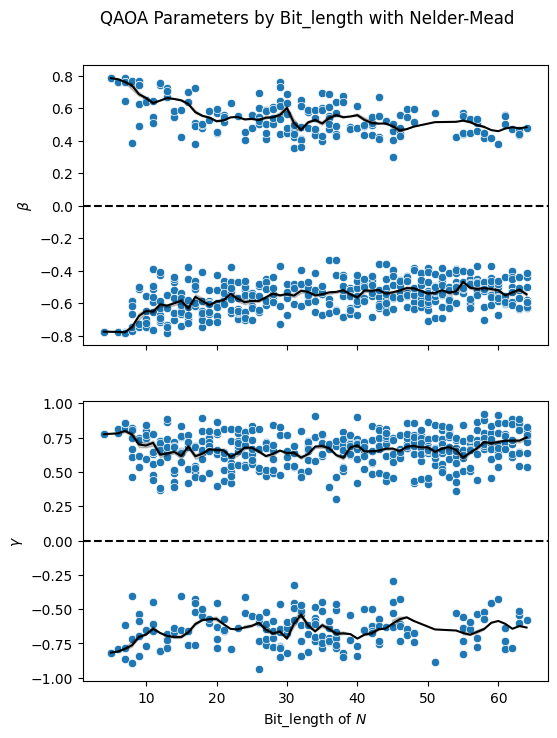

In [14]:
# Read in that data.
parameters_by_bit_length = pd.read_csv('./results/estudio_convergencia_angulos_NelderMead.csv')
parameters_by_bit_length

# Plot gamma and beta by bit-length.
fig, ((ax1), (ax2)) = plt.subplots(2, 1, sharex='all', figsize=(6, 8))

sns.scatterplot(x='Bit_length', y='beta', data=parameters_by_bit_length, ax=ax1)
sns.scatterplot(x='Bit_length', y='gamma', data=parameters_by_bit_length, ax=ax2)


positive_beta = parameters_by_bit_length[parameters_by_bit_length['beta'] > 0]
negative_beta = parameters_by_bit_length[parameters_by_bit_length['beta'] < 0]
positive_gamma = parameters_by_bit_length[parameters_by_bit_length['gamma'] > 0]
negative_gamma = parameters_by_bit_length[parameters_by_bit_length['gamma'] < 0]

window=10
sns.lineplot(x=positive_beta['Bit_length'], y=positive_beta['beta'].rolling(window).mean(), ax=ax1, color='k')
sns.lineplot(x=negative_beta['Bit_length'], y=negative_beta['beta'].rolling(window).mean(), ax=ax1, color='k')
sns.lineplot(x=positive_gamma['Bit_length'], y=positive_gamma['gamma'].rolling(window).mean(), ax=ax2, color='k')
sns.lineplot(x=negative_gamma['Bit_length'], y=negative_gamma['gamma'].rolling(window).mean(), ax=ax2, color='k')

fig.suptitle('QAOA Parameters by Bit_length with Nelder-Mead', y=.95)
ax1.set_ylabel('$\\beta$')
ax2.set_ylabel('$\\gamma$')
ax2.set_xlabel('Bit_length of $N$')

ax1.axhline(0, linestyle='--', color='k')
ax2.axhline(0, linestyle='--', color='k')

ax2.set_xticks(np.arange(start=10, stop=65, step=10))

plt.savefig('./figures/estudio_convergencia_angulos_NelderMead.png', bbox_inches='tight')

#### Mediante COBYLA

In [ ]:
#Cargar los datos
enteros_df = pd.read_csv(f'results/estudio_convergencia_enterosN.csv')

params_by_bitlength = {'Bit_length': [],
                       'beta': [],
                       'gamma': []}

np.random.seed = seed

#Tarda cerca de 10 minutos
for n_bits, N in zip(enteros_df['Bit_length'], enteros_df['N']):
    
    cvp = sl.schnorrCVP(N, c, l, seed = seed, set_seed = False, verbose = False)
    instance = cvp.generate_cvp(q, verbose = False)
    babResult = cvp.babai_algorithm(instance, delta = delta)

    qubo = qaoa.define_qubo(babResult.D, babResult.res_vector, babResult.step_sign, cvp.n)
    Hc, _ = qaoa.define_hamiltonian(qubo)
    
    #Normalizamos el Hamiltoniano
    Hc = normalize_hamiltonian(Hc)

    circuit = qaoa.construct_circuit(Hc, reps = 1)

    _, optparameters = qaoa.qaoa_algorithm(circuit, Hc, min_method = 'COBYLA') #Lo ejecto primero con el metodo por defecto Nelder-Mead

    params_by_bitlength['Bit_length'].append(n_bits)
    params_by_bitlength['beta'].append(optparameters['β[0]'])
    params_by_bitlength['gamma'].append(optparameters['γ[0]'])



In [12]:
df = pd.DataFrame(params_by_bitlength)
df.to_csv(f'results/estudio_convergencia_angulos_COBYLA.csv', index = False)

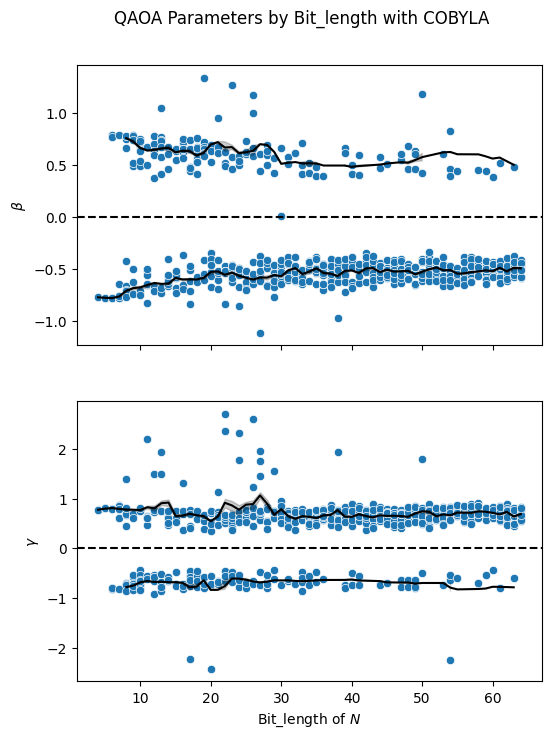

In [6]:
# Read in that data.
parameters_by_bit_length = pd.read_csv('./results/estudio_convergencia_angulos_COBYLA.csv')
parameters_by_bit_length

# Plot gamma and beta by bit-length.
fig, ((ax1), (ax2)) = plt.subplots(2, 1, sharex='all', figsize=(6, 8))

#Hago que los Beta caigan en el rango [-π/2, π/2] y Gamma caiga en el rango [-π, π]
parameters_by_bit_length['beta'] = ((parameters_by_bit_length['beta'] + np.pi/2) % np.pi) - np.pi/2
parameters_by_bit_length['gamma'] = ((parameters_by_bit_length['gamma'] + np.pi) % (2*np.pi)) - np.pi

sns.scatterplot(x='Bit_length', y='beta', data=parameters_by_bit_length, ax=ax1)
sns.scatterplot(x='Bit_length', y='gamma', data=parameters_by_bit_length, ax=ax2)


#Separamos angulos positivos y negativos
positive_beta = parameters_by_bit_length[parameters_by_bit_length['beta'] > 0]
negative_beta = parameters_by_bit_length[parameters_by_bit_length['beta'] < 0]
positive_gamma = parameters_by_bit_length[parameters_by_bit_length['gamma'] > 0]
negative_gamma = parameters_by_bit_length[parameters_by_bit_length['gamma'] < 0]


window=10
sns.lineplot(x=positive_beta['Bit_length'], y=positive_beta['beta'].rolling(window).mean(), ax=ax1, color='k')
sns.lineplot(x=negative_beta['Bit_length'], y=negative_beta['beta'].rolling(window).mean(), ax=ax1, color='k')
sns.lineplot(x=positive_gamma['Bit_length'], y=positive_gamma['gamma'].rolling(window).mean(), ax=ax2, color='k')
sns.lineplot(x=negative_gamma['Bit_length'], y=negative_gamma['gamma'].rolling(window).mean(), ax=ax2, color='k')

fig.suptitle('QAOA Parameters by Bit_length with COBYLA', y=.95)
ax1.set_ylabel('$\\beta$')
ax2.set_ylabel('$\\gamma$')
ax2.set_xlabel('Bit_length of $N$')

ax1.axhline(0, linestyle='--', color='k')
ax2.axhline(0, linestyle='--', color='k')

ax2.set_xticks(np.arange(start=10, stop=65, step=10))
#ax2.set_ylim((-1, 1))
#ax1.set_ylim((-1, 0.8))


plt.savefig('./figures/estudio_convergencia_angulos_COBYLA.png', bbox_inches='tight')